In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [9]:
df = pd.read_csv("Twitter_Data.csv")

# Drop missing values
df = df.dropna(subset=["clean_text", "category"])
df["category"] = df["category"].astype(int)

# Map numeric sentiment labels to text
label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
df["sentiment"] = df["category"].map(label_map)

df[["clean_text", "category", "sentiment"]].head()

,clean_text,category,sentiment
0,when modi promised “minimum government maximum...,-1,Negative
1,talk all the nonsense and continue all the dra...,0,Neutral
2,what did just say vote for modi welcome bjp t...,1,Positive
3,asking his supporters prefix chowkidar their n...,1,Positive
4,answer who among these the most powerful world...,1,Positive


Total tweets: 162969
category
 1    72249
 0    55211
-1    35509
Name: count, dtype: int64
Max length: 274
Min length: 1
Average words per tweet: 20.08070246488596


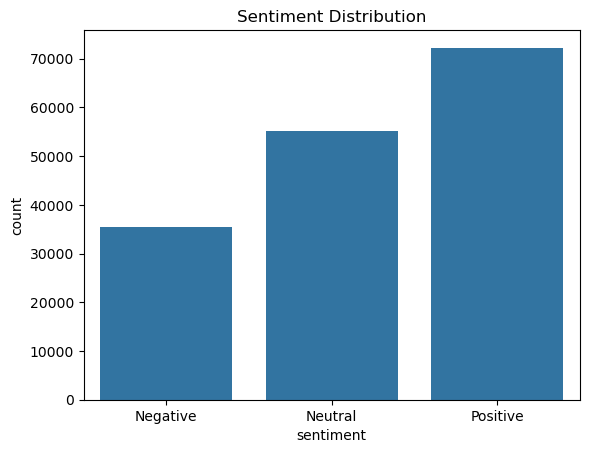

In [10]:
# Total tweets
print("Total tweets:", len(df))

# Distribution of categories
print(df["category"].value_counts())

# Tweet lengths
tweet_lengths = df["clean_text"].str.len()
print("Max length:", tweet_lengths.max())
print("Min length:", tweet_lengths.min())

# Average number of words
avg_words = df["clean_text"].str.split().str.len().mean()
print("Average words per tweet:", avg_words)

# Plot distribution using sentiment labels
sns.countplot(x="sentiment", data=df, order=["Negative","Neutral","Positive"])
plt.title("Sentiment Distribution")
plt.show()

In [11]:
X = df["clean_text"]
y = df["category"]

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression Accuracy: 0.9273179112720132
              precision    recall  f1-score   support

    Negative       0.92      0.83      0.87      7102
     Neutral       0.92      0.98      0.95     11042
    Positive       0.94      0.94      0.94     14450

    accuracy                           0.93     32594
   macro avg       0.92      0.91      0.92     32594
weighted avg       0.93      0.93      0.93     32594



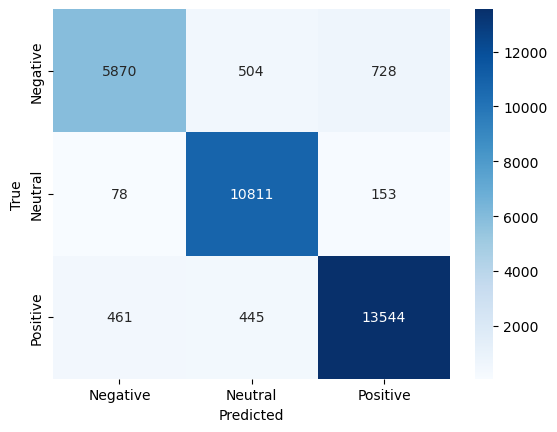

In [14]:
log_reg = LogisticRegression(solver="lbfgs", max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Negative","Neutral","Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.41986255138982637
              precision    recall  f1-score   support

          -1       0.79      0.10      0.18      7102
           0       0.37      0.98      0.54     11042
           1       0.90      0.15      0.26     14450

    accuracy                           0.42     32594
   macro avg       0.69      0.41      0.32     32594
weighted avg       0.70      0.42      0.33     32594

